In [1]:
pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("Unemployment Data.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Clean county column (remove extra spaces)
df['county'] = df['county'].str.strip()

# Add " County" to the end of each county name
df['county'] = df['county'] + " County"

# Save updated file
df.to_csv("Unemployment_Data_Updated.csv", index=False)

print("Successfully added 'County' to all county names.")
print(df['county'].head())

Successfully added 'County' to all county names.
0    Alameda County
1    Alameda County
2    Alameda County
3    Alameda County
4    Alameda County
Name: county, dtype: str


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("crime.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Make sure month column is numeric
df['month'] = pd.to_numeric(df['month'], errors='coerce')

# Convert month number to month name
df['month'] = pd.to_datetime(df['month'], format='%m', errors='coerce').dt.month_name()

# Save updated file
df.to_csv("crime_updated.csv", index=False)

print("Month numbers successfully converted to month names.")
print(df['month'].head())

/tmp/ipykernel_16284/3640051333.py:4: DtypeWarning: Columns (0: Violent_sum, 1: Homicide_sum, 2: ForRape_sum, 3: Robbery_sum, 4: AggAssault_sum, 5: Property_sum, 6: Burglary_sum, 7: VehicleTheft_sum, 8: LTtotal_sum, 9: ViolentClr_sum, 10: HomicideClr_sum, 11: ForRapeClr_sum, 12: RobberyClr_sum, 13: AggAssaultClr_sum, 14: PropertyClr_sum, 15: BurglaryClr_sum, 16: VehicleTheftClr_sum, 17: LTtotalClr_sum, 18: TotalStructural_sum, 19: TotalMobile_sum, 20: TotalOther_sum, 21: GrandTotal_sum, 22: GrandTotClr_sum, 23: RAPact_sum, 24: ARAPact_sum, 25: FROBact_sum, 26: KROBact_sum, 27: OROBact_sum, 28: SROBact_sum, 29: HROBnao_sum, 30: CHROBnao_sum, 31: GROBnao_sum, 32: CROBnao_sum, 33: RROBnao_sum, 34: BROBnao_sum, 35: MROBnao_sum, 36: FASSact_sum, 37: KASSact_sum, 38: OASSact_sum, 39: HASSact_sum, 40: FEBURact_Sum, 41: UBURact_sum, 42: RESDBUR_sum, 43: RNBURnao_sum, 44: RDBURnao_sum, 45: RUBURnao_sum, 46: NRESBUR_sum, 47: NNBURnao_sum, 48: NDBURnao_sum, 49: NUBURnao_sum, 50: MVTact_sum, 51: T

Month numbers successfully converted to month names.
0    January
1    January
2    January
3    January
4    January
Name: month, dtype: str


In [4]:
import pandas as pd

# Load the datasets
crime_df = pd.read_csv("crime_updated.csv")
unemployment_df = pd.read_csv("Unemployment_Data_Updated.csv")

# Optional: Standardize column names (lowercase + strip spaces)
crime_df.columns = crime_df.columns.str.strip().str.lower()
unemployment_df.columns = unemployment_df.columns.str.strip().str.lower()

# Optional: Clean merge key columns (remove extra spaces, standardize case)
for col in ['year', 'county', 'month']:
    crime_df[col] = crime_df[col].astype(str).str.strip().str.lower()
    unemployment_df[col] = unemployment_df[col].astype(str).str.strip().str.lower()

# Merge the datasets
merged_df = pd.merge(
    crime_df,
    unemployment_df,
    on=['year', 'month', 'county'],
    how='inner'   # change to 'left' if you want to keep all crime records
)

# Save the merged file
merged_df.to_csv("merged_output.csv", index=False)

print("Merge complete.")
print("Merged dataset shape:", merged_df.shape)
merged_df.head()

/tmp/ipykernel_16284/2143413297.py:4: DtypeWarning: Columns (0: violent_sum, 1: homicide_sum, 2: forrape_sum, 3: robbery_sum, 4: aggassault_sum, 5: property_sum, 6: burglary_sum, 7: vehicletheft_sum, 8: lttotal_sum, 9: violentclr_sum, 10: homicideclr_sum, 11: forrapeclr_sum, 12: robberyclr_sum, 13: aggassaultclr_sum, 14: propertyclr_sum, 15: burglaryclr_sum, 16: vehicletheftclr_sum, 17: lttotalclr_sum, 18: totalstructural_sum, 19: totalmobile_sum, 20: totalother_sum, 21: grandtotal_sum, 22: grandtotclr_sum, 23: rapact_sum, 24: arapact_sum, 25: frobact_sum, 26: krobact_sum, 27: orobact_sum, 28: srobact_sum, 29: hrobnao_sum, 30: chrobnao_sum, 31: grobnao_sum, 32: crobnao_sum, 33: rrobnao_sum, 34: brobnao_sum, 35: mrobnao_sum, 36: fassact_sum, 37: kassact_sum, 38: oassact_sum, 39: hassact_sum, 40: feburact_sum, 41: uburact_sum, 42: resdbur_sum, 43: rnburnao_sum, 44: rdburnao_sum, 45: ruburnao_sum, 46: nresbur_sum, 47: nnburnao_sum, 48: ndburnao_sum, 49: nuburnao_sum, 50: mvtact_sum, 51: t

Merge complete.
Merged dataset shape: (127396, 75)


,year,county,nciccode,month,violent_sum,homicide_sum,forrape_sum,robbery_sum,aggassault_sum,property_sum,...,aolarnao_sum,lt400nao_sum,lt200400nao_sum,lt200nao_sum,lt50200nao_sum,lt50nao_sum,labor force,employment,unemployment,unemp. rate
0,2010,san bernardino county,Adelanto,january,19,0,1,2,16,68,...,4,7,4,NaN,3,5,"894,500","769,100","125,300",14.0%
1,2010,los angeles county,Agoura Hills,january,1,0,0,1,0,13,...,3,5,2,NaN,0,0,"4,904,800","4,267,400","637,400",13.0%
2,2010,alameda county,Alameda,january,14,0,1,7,6,147,...,19,36,18,NaN,31,34,"785,700","695,900","89,900",11.4%
3,2010,alameda county,Alameda BART,january,5,0,0,4,1,112,...,10,9,17,NaN,12,44,"785,700","695,900","89,900",11.4%
4,2010,alameda county,Alameda Co. Sheriff's Department,january,63,0,1,28,34,217,...,41,31,17,NaN,15,37,"785,700","695,900","89,900",11.4%


In [5]:
# Reorder columns
new_order = ['year', 'month', 'county'] + \
            [col for col in merged_df.columns if col not in ['year', 'month', 'county']]

merged_df = merged_df[new_order]

# Save updated file
merged_df.to_csv("merged_output_reordered.csv", index=False)

print("Columns successfully reordered.")
# Display as table
merged_df.head()

Columns successfully reordered.


,year,month,county,nciccode,violent_sum,homicide_sum,forrape_sum,robbery_sum,aggassault_sum,property_sum,...,aolarnao_sum,lt400nao_sum,lt200400nao_sum,lt200nao_sum,lt50200nao_sum,lt50nao_sum,labor force,employment,unemployment,unemp. rate
0,2010,january,san bernardino county,Adelanto,19,0,1,2,16,68,...,4,7,4,NaN,3,5,"894,500","769,100","125,300",14.0%
1,2010,january,los angeles county,Agoura Hills,1,0,0,1,0,13,...,3,5,2,NaN,0,0,"4,904,800","4,267,400","637,400",13.0%
2,2010,january,alameda county,Alameda,14,0,1,7,6,147,...,19,36,18,NaN,31,34,"785,700","695,900","89,900",11.4%
3,2010,january,alameda county,Alameda BART,5,0,0,4,1,112,...,10,9,17,NaN,12,44,"785,700","695,900","89,900",11.4%
4,2010,january,alameda county,Alameda Co. Sheriff's Department,63,0,1,28,34,217,...,41,31,17,NaN,15,37,"785,700","695,900","89,900",11.4%


In [6]:
!pip install pandas numpy matplotlib scikit-learn statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
df = pd.read_csv('merged_output_reordered.csv')

# 2. Data Cleaning Function
def clean_numeric(column):
    # Remove commas and percentage signs, then convert to numeric
    return pd.to_numeric(df[column].astype(str).str.replace(',', '').str.replace('%', ''), errors='coerce')

# Clean the necessary columns
df['violent_sum'] = clean_numeric('violent_sum')
df['labor force'] = clean_numeric('labor force')
df['unemployment'] = clean_numeric('unemployment')
df['employment'] = clean_numeric('employment')
df['unemp. rate'] = clean_numeric('unemp. rate')

# Handle missing values (dropping rows with NaNs in our chosen columns)
df_clean = df.dropna(subset=['violent_sum', 'labor force', 'unemployment', 'year'])

# 3. Define Features (X) and Target (y)
# We will use year, labor force, and unemployment to predict violent crimes
features = ['year', 'labor force', 'unemployment']
target = 'violent_sum'

X = df_clean[features]
y = df_clean[target]

# 4. Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Make predictions
y_pred = model.predict(X_test)

# 7. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.4f}")

# Display coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nModel Coefficients:")
print(coeff_df)

# Example: Predicting for a specific case
# Predicting for Year 2025, Labor Force 1,000,000, Unemployment 50,000
example_data = np.array([[2025, 1000000, 50000]])
prediction = model.predict(example_data)
print(f"\nPredicted Violent Crimes for example input: {prediction[0]:.2f}")

/tmp/ipykernel_16284/205936679.py:8: DtypeWarning: Columns (0: violent_sum, 1: homicide_sum, 2: forrape_sum, 3: robbery_sum, 4: aggassault_sum, 5: property_sum, 6: burglary_sum, 7: vehicletheft_sum, 8: lttotal_sum, 9: violentclr_sum, 10: homicideclr_sum, 11: forrapeclr_sum, 12: robberyclr_sum, 13: aggassaultclr_sum, 14: propertyclr_sum, 15: burglaryclr_sum, 16: vehicletheftclr_sum, 17: lttotalclr_sum, 18: totalstructural_sum, 19: totalmobile_sum, 20: totalother_sum, 21: grandtotal_sum, 22: grandtotclr_sum, 23: rapact_sum, 24: arapact_sum, 25: frobact_sum, 26: krobact_sum, 27: orobact_sum, 28: srobact_sum, 29: hrobnao_sum, 30: chrobnao_sum, 31: grobnao_sum, 32: crobnao_sum, 33: rrobnao_sum, 34: brobnao_sum, 35: mrobnao_sum, 36: fassact_sum, 37: kassact_sum, 38: oassact_sum, 39: hassact_sum, 40: feburact_sum, 41: uburact_sum, 42: resdbur_sum, 43: rnburnao_sum, 44: rdburnao_sum, 45: ruburnao_sum, 46: nresbur_sum, 47: nnburnao_sum, 48: ndburnao_sum, 49: nuburnao_sum, 50: mvtact_sum, 51: tm

Model Performance:
Mean Squared Error: 9836.04
R-squared: 0.0130

Model Coefficients:
              Coefficient
year             0.239847
labor force      0.000008
unemployment    -0.000025

Predicted Violent Crimes for example input: 21.69


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Load the dataset
# Setting low_memory=False to handle mixed types in your large file
df = pd.read_csv('merged_output_reordered.csv', low_memory=False)

# 2. Data Cleaning Function
# This handles commas (1,000), percentage signs (5%), and empty spaces
def clean_numeric(val):
    if pd.isna(val):
        return None
    s = str(val).replace(',', '').replace('%', '').strip()
    if s == '' or s == '-':
        return None
    try:
        return float(s)
    except ValueError:
        return None

# Clean the specific columns we want to use
df['violent_sum_clean'] = df['violent_sum'].apply(clean_numeric)
df['unemployment_clean'] = df['unemployment'].apply(clean_numeric)

# Drop rows where our chosen columns are missing data
df_model = df.dropna(subset=['violent_sum_clean', 'unemployment_clean'])

# 3. Define the simple relationship
# X must be a 2D array/DataFrame, y must be 1D
X = df_model[['unemployment_clean']] 
y = df_model['violent_sum_clean']

# 4. Split the data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Evaluate the model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"Simple Linear Regression Results:")
print(f"Slope (Coefficient): {model.coef_[0]:.6f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R-squared: {r2:.4f}")

# 7. Make a prediction
# Example: What is the predicted violent crime sum if unemployment is 50,000?
test_val = [[50000]]
prediction = model.predict(test_val)
print(f"\nPrediction for 50,000 unemployed: {prediction[0]:.2f} violent crimes")

Simple Linear Regression Results:
Slope (Coefficient): 0.000060
Intercept: 15.14
R-squared: 0.0117

Prediction for 50,000 unemployed: 18.16 violent crimes


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Model Equation: y = 0.000062x + 22.64


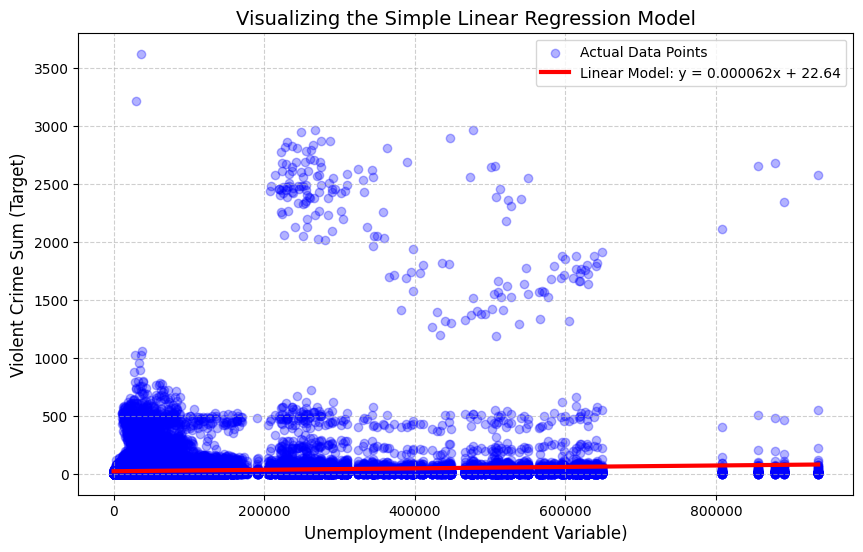

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Load and clean data
df = pd.read_csv('merged_output_reordered.csv', low_memory=False)

def clean_numeric(val):
    if pd.isna(val): return None
    s = str(val).replace(',', '').replace('%', '').strip()
    if s == '' or s == '-': return None
    try: return float(s)
    except ValueError: return None

df['violent_sum_clean'] = df['violent_sum'].apply(clean_numeric)
df['unemployment_clean'] = df['unemployment'].apply(clean_numeric)

# Remove missing values and zeros for a clearer model
df_clean = df.dropna(subset=['violent_sum_clean', 'unemployment_clean'])
df_clean = df_clean[(df_clean['violent_sum_clean'] > 0) & (df_clean['unemployment_clean'] > 0)]

# 2. Build the Model
X = df_clean[['unemployment_clean']]
y = df_clean['violent_sum_clean']
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

# 3. Represent the model as an actual Equation
print(f"Model Equation: y = {slope:.6f}x + {intercept:.2f}")

# 4. Create the Visual Model
plt.figure(figsize=(10, 6))

# Plot the raw data points
plt.scatter(X, y, alpha=0.3, color='blue', label='Actual Data Points')

# Create the "Model Line" (Line of Best Fit)
X_range = np.linspace(X.min(), X.max(), 100)
y_range = slope * X_range + intercept
plt.plot(X_range, y_range, color='red', linewidth=3, 
         label=f'Linear Model: y = {slope:.6f}x + {intercept:.2f}')

# Formatting the plot
plt.title('Visualizing the Simple Linear Regression Model', fontsize=14)
plt.xlabel('Unemployment (Independent Variable)', fontsize=12)
plt.ylabel('Violent Crime Sum (Target)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Save and show
plt.savefig('regression_model_plot.png')

--- K-Fold Validation Results ---
Fold 1 R-squared: 0.0064
Fold 2 R-squared: 0.0070
Fold 3 R-squared: 0.0076
Fold 4 R-squared: 0.0057
Fold 5 R-squared: 0.0057

Average R-squared across all folds: 0.0065
Average Mean Squared Error: 13324.31


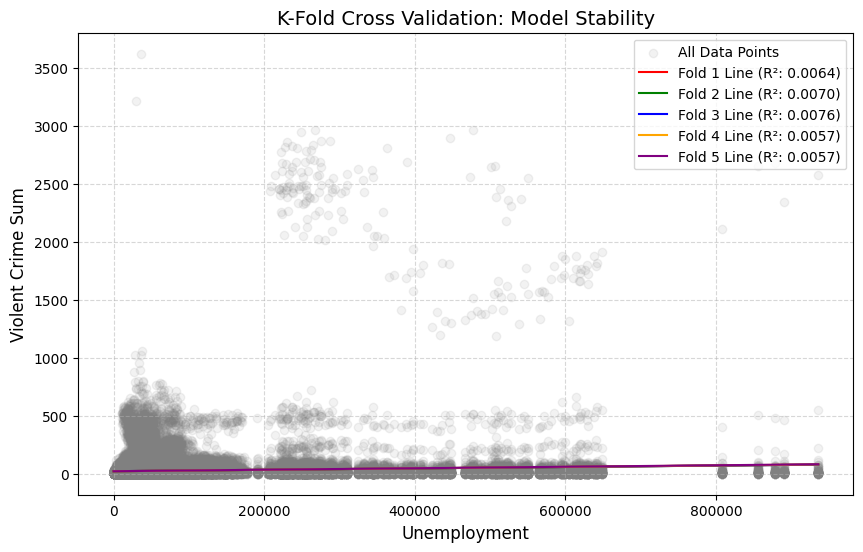

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load and clean the data
df = pd.read_csv('merged_output_reordered.csv', low_memory=False)

def clean_numeric(val):
    if pd.isna(val): return None
    s = str(val).replace(',', '').replace('%', '').strip()
    if s == '' or s == '-': return None
    try: return float(s)
    except ValueError: return None

df['violent_sum_clean'] = df['violent_sum'].apply(clean_numeric)
df['unemployment_clean'] = df['unemployment'].apply(clean_numeric)

# Drop missing values and zeros for a cleaner visualization
df_clean = df.dropna(subset=['violent_sum_clean', 'unemployment_clean'])
df_clean = df_clean[(df_clean['violent_sum_clean'] > 0) & (df_clean['unemployment_clean'] > 0)]

# Features (X) and Target (y)
X = df_clean[['unemployment_clean']].values
y = df_clean['violent_sum_clean'].values

# 2. Setup K-Fold (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []
mse_scores = []

# Prepare the plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.1, color='gray', label='All Data Points')
colors = ['red', 'green', 'blue', 'orange', 'purple']
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# 3. Perform the Cross-Validation Loop
for i, (train_index, test_index) in enumerate(kf.split(X)):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train the model for this specific fold
    fold_model = LinearRegression()
    fold_model.fit(X_train, y_train)
    
    # Predict and evaluate performance for this fold
    y_pred = fold_model.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))
    
    # Draw the regression line for this fold
    y_range = fold_model.predict(X_range)
    plt.plot(X_range, y_range, color=colors[i], 
             label=f'Fold {i+1} Line (R²: {r2_scores[i]:.4f})')

# 4. Show the Final "Actual" Model Metrics
print(f"--- K-Fold Validation Results ---")
for i, score in enumerate(r2_scores):
    print(f"Fold {i+1} R-squared: {score:.4f}")

print(f"\nAverage R-squared across all folds: {np.mean(r2_scores):.4f}")
print(f"Average Mean Squared Error: {np.mean(mse_scores):.2f}")

# Finalizing the visual model
plt.title('K-Fold Cross Validation: Model Stability', fontsize=14)
plt.xlabel('Unemployment', fontsize=12)
plt.ylabel('Violent Crime Sum', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('kfold_regression_plot.png')

In [11]:
import pandas as pd

# Load the dataset
df = pd.read_csv('merged_output_reordered.csv')

# Define the specific columns to keep
columns_to_keep = [
    'property_sum', 
    'violent_sum',  
    'year', 
    'month', 
    'county', 
    'unemp. rate'
]

# Drop all other columns by selecting only those in the list
df_filtered = df[columns_to_keep]

# Save the transformed data to a new CSV file
df_filtered.to_csv('filtered_data.csv', index=False)

# Display the first few rows to verify
print(df_filtered.head())

/tmp/ipykernel_16284/139731172.py:4: DtypeWarning: Columns (0: violent_sum, 1: homicide_sum, 2: forrape_sum, 3: robbery_sum, 4: aggassault_sum, 5: property_sum, 6: burglary_sum, 7: vehicletheft_sum, 8: lttotal_sum, 9: violentclr_sum, 10: homicideclr_sum, 11: forrapeclr_sum, 12: robberyclr_sum, 13: aggassaultclr_sum, 14: propertyclr_sum, 15: burglaryclr_sum, 16: vehicletheftclr_sum, 17: lttotalclr_sum, 18: totalstructural_sum, 19: totalmobile_sum, 20: totalother_sum, 21: grandtotal_sum, 22: grandtotclr_sum, 23: rapact_sum, 24: arapact_sum, 25: frobact_sum, 26: krobact_sum, 27: orobact_sum, 28: srobact_sum, 29: hrobnao_sum, 30: chrobnao_sum, 31: grobnao_sum, 32: crobnao_sum, 33: rrobnao_sum, 34: brobnao_sum, 35: mrobnao_sum, 36: fassact_sum, 37: kassact_sum, 38: oassact_sum, 39: hassact_sum, 40: feburact_sum, 41: uburact_sum, 42: resdbur_sum, 43: rnburnao_sum, 44: rdburnao_sum, 45: ruburnao_sum, 46: nresbur_sum, 47: nnburnao_sum, 48: ndburnao_sum, 49: nuburnao_sum, 50: mvtact_sum, 51: tm

  property_sum violent_sum  year    month                 county unemp. rate
0           68          19  2010  january  san bernardino county       14.0%
1           13           1  2010  january     los angeles county       13.0%
2          147          14  2010  january         alameda county       11.4%
3          112           5  2010  january         alameda county       11.4%
4          217          63  2010  january         alameda county       11.4%


In [12]:
import pandas as pd

# Load the filtered dataset
df = pd.read_csv('filtered_data.csv')

# Define the new column order
new_order = [
    'year', 
    'month', 
    'county', 
    'property_sum', 
    'violent_sum', 
    'unemp. rate'
]

# Rearrange the columns by re-selecting them in the new order
df_reordered = df[new_order]

# Save the rearranged data to a new CSV file
df_reordered.to_csv('reordered_filtered_data.csv', index=False)

# Display the result to verify the column order
print(df_reordered.head())

   year    month                 county property_sum violent_sum unemp. rate
0  2010  january  san bernardino county           68          19       14.0%
1  2010  january     los angeles county           13           1       13.0%
2  2010  january         alameda county          147          14       11.4%
3  2010  january         alameda county          112           5       11.4%
4  2010  january         alameda county          217          63       11.4%


In [13]:
import pandas as pd

# Load the dataset
df = pd.read_csv('reordered_filtered_data.csv')

# Display the first 10 rows as a plain text table
# index=False removes the row numbers on the left
print(df.head(10).to_string(index=False))

 year   month                county property_sum violent_sum unemp. rate
 2010 january san bernardino county           68          19       14.0%
 2010 january    los angeles county           13           1       13.0%
 2010 january        alameda county          147          14       11.4%
 2010 january        alameda county          112           5       11.4%
 2010 january        alameda county          217          63       11.4%
 2010 january        alameda county            1           0       11.4%
 2010 january        alameda county           13           0       11.4%
 2010 january        alameda county           41           4       11.4%
 2010 january    los angeles county          206          19       13.0%
 2010 january         orange county           47           2       10.3%


## Lag - 3 months 

In [14]:
import pandas as pd

# Load the dataset
df = pd.read_csv('reordered_filtered_data.csv')

# 1. Map month names to numbers for correct chronological sorting
month_map = {
    'january': 1, 'february': 2, 'march': 3, 'april': 4, 'may': 5, 'june': 6,
    'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12
}
df['month_num'] = df['month'].str.lower().map(month_map)

# 2. Sort by county, year, and month
df = df.sort_values(by=['county', 'year', 'month_num'])

# 3. Create 3-month lag columns for the numerical features
# Grouping by 'county' ensures the lag stays within the same location
cols_to_lag = ['property_sum', 'violent_sum', 'unemp. rate']

for col in cols_to_lag:
    df[f'{col}_lag3'] = df.groupby('county')[col].shift(3)

# 4. Remove the helper column and save the result
df = df.drop(columns=['month_num'])
df.to_csv('lagged_data.csv', index=False)

# Display the first few rows to verify the lag columns
print(df.head(10).to_string(index=False))

 year   month         county property_sum violent_sum unemp. rate property_sum_lag3 violent_sum_lag3 unemp. rate_lag3
 2010 january alameda county          147          14       11.4%               NaN              NaN              NaN
 2010 january alameda county          112           5       11.4%               NaN              NaN              NaN
 2010 january alameda county          217          63       11.4%               NaN              NaN              NaN
 2010 january alameda county            1           0       11.4%               147               14            11.4%
 2010 january alameda county           13           0       11.4%               112                5            11.4%
 2010 january alameda county           41           4       11.4%               217               63            11.4%
 2010 january alameda county          606          40       11.4%                 1                0            11.4%
 2010 january alameda county           16           1   

## Lag - 6 months 

In [15]:
import pandas as pd

# Load the dataset
df = pd.read_csv('reordered_filtered_data.csv')

# 1. Map month names to numbers for correct chronological sorting
month_map = {
    'january': 1, 'february': 2, 'march': 3, 'april': 4, 'may': 5, 'june': 6,
    'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12
}
df['month_num'] = df['month'].str.lower().map(month_map)

# 2. Sort by county, year, and month
df = df.sort_values(by=['county', 'year', 'month_num'])

# 3. Create 6-month lag columns for the numerical features
# Grouping by 'county' ensures the lag stays within the same location
cols_to_lag = ['property_sum', 'violent_sum', 'unemp. rate']

for col in cols_to_lag:
    df[f'{col}_lag6'] = df.groupby('county')[col].shift(6)

# 4. Remove the helper column and save the result
df = df.drop(columns=['month_num'])
df.to_csv('lagged_data.csv', index=False)

# Display the first few rows to verify the lag columns
print(df.head(10).to_string(index=False))

 year   month         county property_sum violent_sum unemp. rate property_sum_lag6 violent_sum_lag6 unemp. rate_lag6
 2010 january alameda county          147          14       11.4%               NaN              NaN              NaN
 2010 january alameda county          112           5       11.4%               NaN              NaN              NaN
 2010 january alameda county          217          63       11.4%               NaN              NaN              NaN
 2010 january alameda county            1           0       11.4%               NaN              NaN              NaN
 2010 january alameda county           13           0       11.4%               NaN              NaN              NaN
 2010 january alameda county           41           4       11.4%               NaN              NaN              NaN
 2010 january alameda county          606          40       11.4%               147               14            11.4%
 2010 january alameda county           16           1   

## Lag - 9 months 

In [16]:
import pandas as pd

# Load the dataset
df = pd.read_csv('reordered_filtered_data.csv')

# 1. Map month names to numbers for correct chronological sorting
month_map = {
    'january': 1, 'february': 2, 'march': 3, 'april': 4, 'may': 5, 'june': 6,
    'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12
}
df['month_num'] = df['month'].str.lower().map(month_map)

# 2. Sort by county, year, and month
df = df.sort_values(by=['county', 'year', 'month_num'])

# 3. Create 9-month lag columns for the numerical features
# Grouping by 'county' ensures the lag stays within the same location
cols_to_lag = ['property_sum', 'violent_sum', 'unemp. rate']

for col in cols_to_lag:
    df[f'{col}_lag9'] = df.groupby('county')[col].shift(9)

# 4. Remove the helper column and save the result
df = df.drop(columns=['month_num'])
df.to_csv('lagged_data.csv', index=False)

# Display the first few rows to verify the lag columns
print(df.head(10).to_string(index=False))

 year   month         county property_sum violent_sum unemp. rate property_sum_lag9 violent_sum_lag9 unemp. rate_lag9
 2010 january alameda county          147          14       11.4%               NaN              NaN              NaN
 2010 january alameda county          112           5       11.4%               NaN              NaN              NaN
 2010 january alameda county          217          63       11.4%               NaN              NaN              NaN
 2010 january alameda county            1           0       11.4%               NaN              NaN              NaN
 2010 january alameda county           13           0       11.4%               NaN              NaN              NaN
 2010 january alameda county           41           4       11.4%               NaN              NaN              NaN
 2010 january alameda county          606          40       11.4%               NaN              NaN              NaN
 2010 january alameda county           16           1   

## Random Forest

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
df = pd.read_csv('filtered_data.csv')

# 2. Data Cleaning
# Convert numerical columns to float, handling any empty strings or errors
numeric_cols = ['property_sum', 'violent_sum']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean 'unemp. rate' by removing '%' and converting to float
df['unemp. rate'] = pd.to_numeric(df['unemp. rate'].astype(str).str.replace('%', '', regex=False), errors='coerce')

# Drop any rows with missing values (NaN) so the model can process the data
df_clean = df.dropna()

# 3. Encoding Categorical Variables
# Convert 'month' and 'county' into dummy/indicator variables
df_ml = pd.get_dummies(df_clean, columns=['month', 'county'], drop_first=True)

# 4. Define Target and Features
# We are predicting '' using all other available information
target = '
features = ['year', 'unemp. rate', 'property_sum', 'violent_sum'] + \
           [col for col in df_ml.columns if 'month_' in col or 'county_' in col]

X = df_ml[features]
y = df_ml[target]

# 5. Train/Test Split
# Split data: 80% for training and 20% for testing the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize and Train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 7. Model Evaluation
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-Squared Score: {r2:.4f}")

# Display feature importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop 5 Important Features:")
print(importances.head(5))

KeyError: 'grandtotclr_sum'

## Multiple Linear Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
df = pd.read_csv('filtered_data.csv')

# 2. Data Preprocessing
# Remove '%' from 'unemp. rate' and convert to float
df['unemp. rate'] = df['unemp. rate'].str.replace('%', '').astype(float)

# Ensure clearance sums are numeric (handling any potential non-numeric strings)
cols_to_numeric = ['property_sum', 'violent_sum']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing values created during cleaning
df = df.dropna()

# 3. Feature Selection
# We use numeric columns and 'month' (which we will encode)
# 'county' is excluded here for simplicity, but could be added via dummies
X = df[['property_sum', 'violent_sum', 'year', 'month']]
y = df['unemp. rate']

# One-hot encode the 'month' column to convert categories into numeric columns
X = pd.get_dummies(X, columns=['month'], drop_first=True) 

# 4. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Model Evaluation
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Performance ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

print("\n--- Coefficients ---")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

## 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load and Clean Data
df = pd.read_csv('filtered_data.csv')
df['unemp. rate'] = df['unemp. rate'].str.replace('%', '').astype(float)

cols_to_fix = ['propertyclr_sum', 'violentclr_sum', 'grandtotclr_sum']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

# 2. Prepare Features (X) and Target (y)
X = df[['propertyclr_sum', 'violentclr_sum', 'grandtotclr_sum', 'year', 'month']]
y = df['unemp. rate']

# One-hot encoding for categorical variables
X = pd.get_dummies(X, columns=['month'], drop_first=True)

# 3. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. Visualization (Matplotlib only)

# Plot 1: Actual vs Predicted
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Unemployment Rate (%)')
plt.ylabel('Predicted Unemployment Rate (%)')
plt.title('Actual vs Predicted')
plt.savefig('actual_vs_predicted.png')
plt.close()

# Plot 2: Distribution of Residuals
residuals = y_test - y_pred
plt.hist(residuals, bins=30, color='purple', edgecolor='black')
plt.xlabel('Residual (Error)')
plt.ylabel('Count')
plt.title('Residual Distribution')
plt.savefig('residuals_dist.png')
plt.close()

# Plot 3: Feature Importance (Coefficients)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coef': model.coef_}).sort_values(by='Coef')
plt.barh(coef_df['Feature'], coef_df['Coef'], color='teal')
plt.xlabel('Coefficient Value')
plt.title('Impact of Features on Unemployment')
plt.tight_layout()
plt.savefig('coefficients.png')
plt.close()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load and Clean Data
df = pd.read_csv('filtered_data.csv')

# Clean unemployment rate (remove % and convert to float)
df['unemp. rate'] = df['unemp. rate'].str.replace('%', '').astype(float)

# Ensure clearance column is numeric
df['grandtotclr_sum'] = pd.to_numeric(df['grandtotclr_sum'], errors='coerce')

# Drop rows with NaN values resulting from cleaning
df = df.dropna(subset=['unemp. rate', 'grandtotclr_sum'])

# 2. Select Features and Target
# Simple regression uses exactly ONE feature
X = df[['grandtotclr_sum']]
y = df['unemp. rate']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = model.predict(X_test)

# 6. Performance Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Model Equation: y = {model.intercept_:.4f} + ({model.coef_[0]:.4f})x")

# 7. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.1, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Grand Total Clearance Sum')
plt.ylabel('Unemployment Rate (%)')
plt.title('Simple Linear Regression: Clearance vs Unemployment')
plt.legend()
plt.savefig('simple_regression_plot.png')